# 01 — Buy-and-hold baseline

This notebook establishes the benchmark used by every later strategy. The strategy holds one unit of exposure throughout the sample. Costs are charged once at entry, so the benchmark column shows the frictionless asset return while the strategy column shows the cost-aware portfolio.

> Educational research only; this is not financial advice.

<div style="border-left: 5px solid #2563EB; padding: 0.85em 1em; margin: 1em 0 1.4em; background: #F8FAFC; border-radius: 8px;">
<strong>🧭 Reader guide</strong><br>
Start with the assumptions, then follow the data and rule definitions. The tables and charts report the formal test period. Finish with <strong>What went well / what went wrong</strong> — that is where the research judgment and limitations are made explicit.
</div>


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.backtest import run_backtest
from src.data import load_price_data, make_demo_ohlcv
from src.plots import monthly_returns, plot_drawdown, plot_equity_curve

# Consistent visual language across the research library.
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "axes.facecolor": "#F8FAFC",
    "axes.edgecolor": "#CBD5E1",
    "axes.grid": True,
    "grid.color": "#CBD5E1",
    "grid.alpha": 0.35,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelcolor": "#334155",
    "xtick.color": "#475569",
    "ytick.color": "#475569",
    "legend.frameon": False,
    "figure.autolayout": True,
})


## 📦 Data and assumptions

- Asset: SPY, daily adjusted OHLCV
- Sample: 2010–2025
- Initial capital: $100,000
- Transaction cost: 10 bps per unit of exposure change
- Signal timing: exposure is shifted one bar before returns are applied

Set `USE_DEMO_DATA = True` for a deterministic offline run. The synthetic series is for testing the workflow, not for making claims about markets.

In [2]:
USE_DEMO_DATA = False
if USE_DEMO_DATA:
    prices = make_demo_ohlcv(periods=2_000, seed=11)
else:
    try:
        prices = load_price_data('SPY', '2010-01-01', '2026-01-01')
    except Exception as exc:
        print(f'Live download unavailable ({exc}); using deterministic demo data.')
        prices = make_demo_ohlcv(periods=2_000, seed=11)

prices.tail()

,open,high,low,close,volume
Date,,,,,
2025-12-24,684.313382,687.178163,684.164151,686.730530,39445600.0
2025-12-26,686.989161,688.003728,685.626408,686.660889,41613300.0
2025-12-29,683.905508,685.556767,682.443308,684.213867,62559500.0
2025-12-30,683.816033,684.920151,682.950637,683.378357,47160700.0
2025-12-31,683.507684,683.726492,678.106396,678.315247,74144800.0


In [3]:
target = pd.Series(1.0, index=prices.index, name='target_position')
result = run_backtest(
    prices['close'],
    target,
    initial_capital=100_000,
    transaction_cost_bps=10,
)

metrics = pd.Series(result.metrics).to_frame('buy_and_hold')
metrics.style.format({
    'annualized_return': '{:.2%}',
    'annualized_volatility': '{:.2%}',
    'sharpe_ratio': '{:.2f}',
    'sortino_ratio': '{:.2f}',
    'max_drawdown': '{:.2%}',
    'calmar_ratio': '{:.2f}',
    'win_rate': '{:.2%}',
    'annualized_turnover': '{:.2f}',
    'number_of_trades': '{:.0f}',
    'total_return_after_costs': '{:.2%}',
    'benchmark_total_return': '{:.2%}',
    'benchmark_relative_return': '{:.2%}',
})

,buy_and_hold
annualized_return,0.139189
annualized_volatility,0.172076
sharpe_ratio,0.843769
sortino_ratio,1.188435
max_drawdown,-0.337173
calmar_ratio,0.412813
win_rate,0.555722
annualized_turnover,0.062624
number_of_trades,1.000000
total_return_after_costs,7.011950


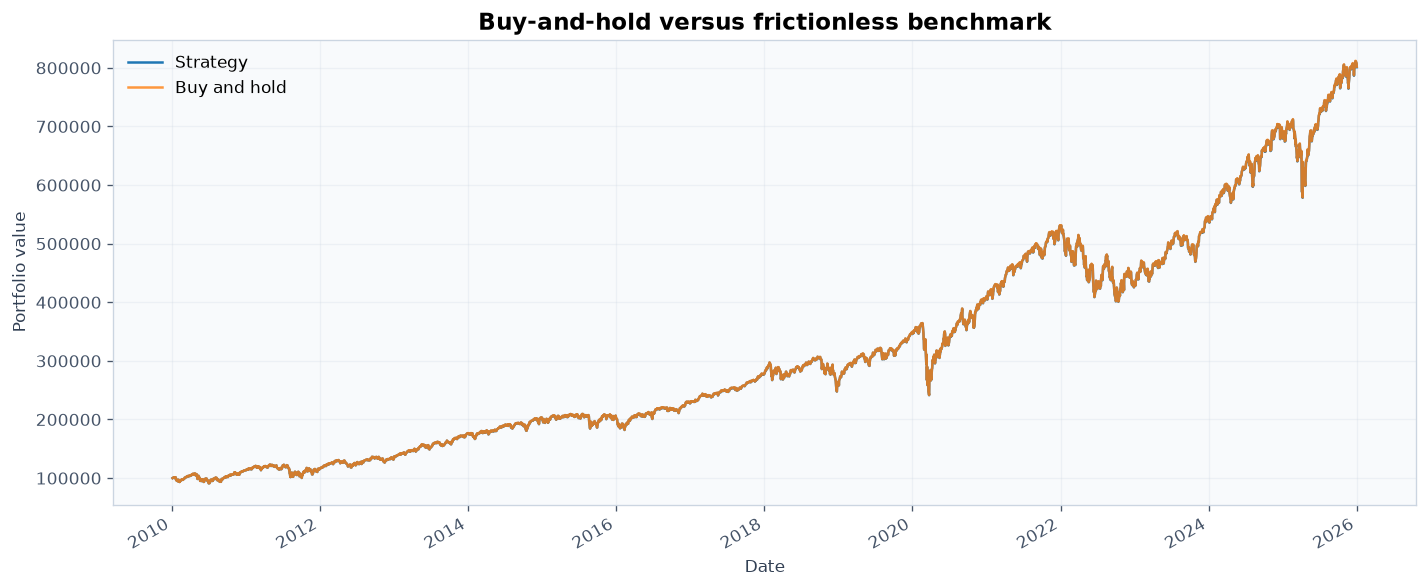

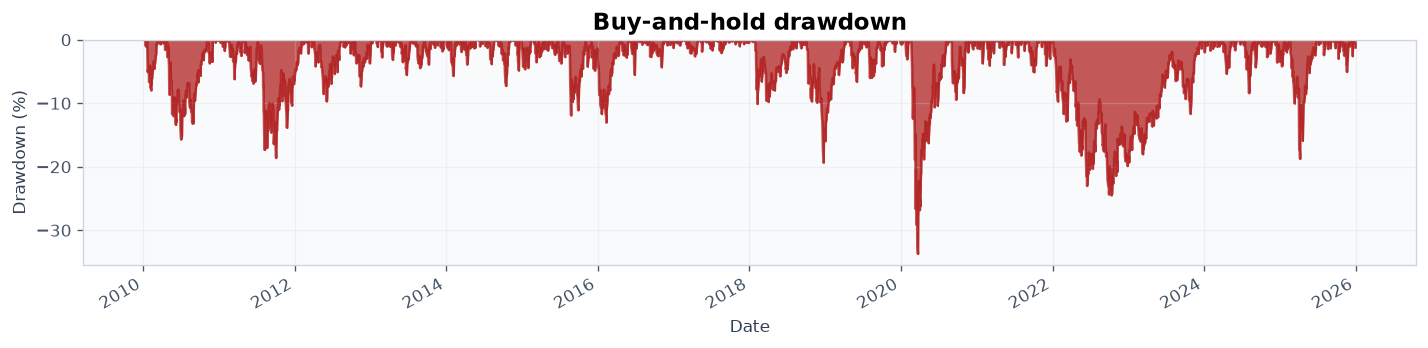

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2010,-5.34%,3.12%,6.09%,1.55%,-7.95%,-5.17%,6.83%,-4.50%,8.96%,3.82%,-0.00%,6.69%
2011,2.33%,3.47%,0.01%,2.90%,-1.12%,-1.69%,-2.00%,-5.50%,-6.94%,10.91%,-0.41%,1.04%
2012,4.64%,4.34%,3.22%,-0.67%,-6.01%,4.06%,1.18%,2.51%,2.54%,-1.82%,0.57%,0.89%
2013,5.12%,1.28%,3.80%,1.92%,2.36%,-1.33%,5.17%,-3.00%,3.16%,4.63%,2.96%,2.59%
2014,-3.52%,4.55%,0.83%,0.70%,2.32%,2.06%,-1.34%,3.95%,-1.38%,2.36%,2.75%,-0.25%
2015,-2.96%,5.62%,-1.57%,0.98%,1.29%,-2.03%,2.26%,-6.10%,-2.55%,8.51%,0.37%,-1.73%
2016,-4.98%,-0.08%,6.73%,0.39%,1.70%,0.35%,3.65%,0.12%,0.01%,-1.73%,3.68%,2.03%
2017,1.79%,3.93%,0.12%,0.99%,1.41%,0.64%,2.06%,0.29%,2.01%,2.36%,3.06%,1.21%
2018,5.64%,-3.64%,-2.74%,0.52%,2.43%,0.58%,3.70%,3.19%,0.59%,-6.91%,1.85%,-8.80%


In [4]:
plot_equity_curve(result.frame, title='Buy-and-hold versus frictionless benchmark')
plt.show()
plot_drawdown(result.frame, title='Buy-and-hold drawdown')
plt.show()
monthly_returns(result.frame).style.format('{:.2%}', na_rep='')

## 🧠 Baseline interpretation

This is not a strategy claim. It is a control. Any later strategy should explain why it improves risk-adjusted or drawdown-adjusted behavior relative to this baseline after the same costs, and should also make clear when it does not.

## ⚖️ What went well / what went wrong

**What went well:** Buy-and-hold is a transparent baseline with almost no turnover, minimal implementation complexity, and no parameter-selection risk. It tells us what a strategy must improve on.

**What went wrong:** It carries the full market drawdown and cannot protect capital during prolonged declines. It is also not an alpha claim: it is the benchmark control. A later strategy that earns less but reduces drawdown must explain why that tradeoff is useful.

On the current live run, use the benchmark return, maximum drawdown, and Sharpe shown above as the hurdle for every later notebook.